# Estimación de peso de pollos

## Colegio de Posgraduados

### COA661 Inteligencia Artificial

Profesor: Dr. Juan Manuel González Camacho

Entrega: José Alfredo Martínez

Este notebook realiza la descomposición de video en imágenes para crear el dataset de peso de pollos.

In [1]:
# Librerías
import os
import cv2
import matplotlib.pyplot as plt

## Código

In [2]:
# Configuración
path = './Videos01'
archivos = os.listdir(path)

print('Videos encontrados: ', len(archivos))
print(archivos)

salida1 = './Fotogramas'
salida2 = './Granja'

if not os.path.exists(salida1):
    os.makedirs(salida1)

if not os.path.exists(salida2):
    os.makedirs(salida2)

Videos encontrados:  37
['1.755Kg.mp4', '1.775Kg.mp4', '1.890Kg.mp4', '1.895Kg.mp4', '1.920Kg.mp4', '2.105Kg.mp4', '2.140Kg.mp4', '2.165Kg.mp4', '2.200Kg.mp4', '2.205Kg.mp4', '2.305Kg.mp4', '2.330Kg.mp4', '2.335Kg.mp4', '2.350Kg.mp4', '2.385Kg.mp4', '2.445Kg.mp4', '2.460Kg.mp4', '2.500Kg.mp4', '2.520Kg.mp4', '2.525Kg.mp4', '2.600Kg.mp4', '2.605Kg.mp4', '2.635Kg.mp4', '2.655Kg.mp4', '2.665Kg.mp4', '2.675Kg.mp4', '2.680Kg.mp4', '2.695Kg.mp4', '2.705Kg.mp4', '2.735Kg.mp4', '2.760Kg.mp4', '2.765Kg.mp4', '2.775Kg.mp4', '2.860Kg.mp4', '2.940Kg.mp4', '2.995Kg.mp4', 'Video1.mp4']


In [3]:
# Ciclo principal de acceso a la carpeta
for archivo in archivos:
    datos = archivo.split('Kg')

    if len(datos) > 1:
        peso = datos[0]
        video = cv2.VideoCapture(path + '/' + archivo)

        i = 1
        while True:
            valor, fotograma = video.read()

            if valor and i <= 100:
                # Existe el fotograma
                nombre = f'{salida1}/{peso}kg_{i:05}.jpg'
                i += 1

                alto = 256
                ancho = int(fotograma.shape[1] * alto / fotograma.shape[0])                
                dim = (ancho, alto)

                # 3. Redimensionar
                imagen = cv2.resize(fotograma, dim, interpolation = cv2.INTER_AREA)
                cv2.imwrite(nombre, imagen)

            else:
                # Ya no hay fotograma o el contador es mayor a 50
                break;

        video.release()

fotos = os.listdir(salida1)
print('Imagenes creadas: ', len(fotos))

Imagenes creadas:  3118


In [4]:
# Convertir el video de la granja en fotos
video = cv2.VideoCapture(path + '/Video1.mp4')

i = 0
while True:
    valor, fotograma = video.read()

    if valor:
        # Existe el fotograma
        nombre = f'{salida2}/Granja_{i:05}.jpg'
        i += 1

        alto = 256
        ancho = int(fotograma.shape[1] * alto / fotograma.shape[0])                
        dim = (ancho, alto)

        # 3. Redimensionar
        imagen = cv2.resize(fotograma, dim, interpolation = cv2.INTER_AREA)
        cv2.imwrite(nombre, imagen)

    else:
        # Ya no hay fotograma
        break;

video.release()

fotos = os.listdir(salida2)
print('Imagenes creadas: ', len(fotos))

Imagenes creadas:  2426


Imprimir muestras de los fotogramas.

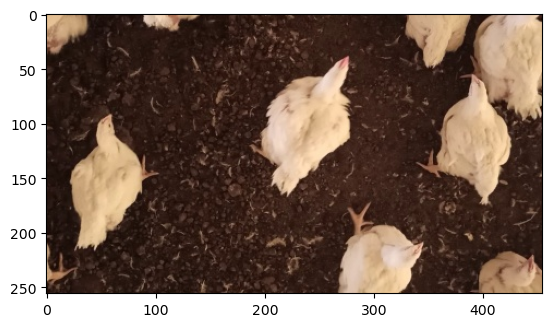

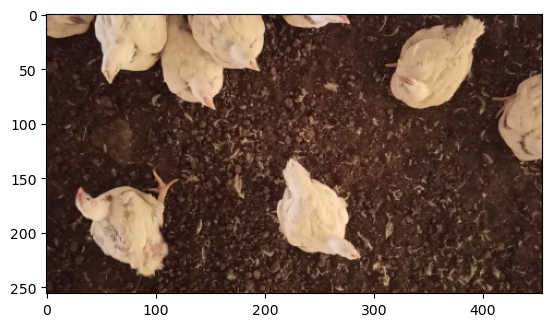

In [5]:
imagen = plt.imread(salida2 + '/' + fotos[0])
plt.imshow(imagen)
plt.show()

imagen = plt.imread(salida2 + '/' + fotos[-1])
plt.imshow(imagen)
plt.show()